In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
df = pd.read_csv('netflix_dataset.csv')

# Convert release date to proper datetime format
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Year'] = df['Release_Date'].dt.year

# If multiple countries listed, keep only the first one
df['Country'] = df['Country'].dropna().apply(lambda x: x.split(',')[0].strip())

# Drop rows where these important columns are missing
df.dropna(subset=['Category', 'Rating', 'Year'], inplace=True)

print("Dataset loaded successfully!")
print(f"Total rows after cleaning: {len(df):,}")

In [ ]:
# Count movies vs tv shows
cat_counts = df['Category'].value_counts()

# Top 8 countries with most content
top_country = df['Country'].value_counts().head(8)

# Most common content ratings
top_rating = df['Rating'].value_counts().head(8)

# Year wise trend from 2000 onwards
trend = df[df['Year'] >= 2000].groupby(
    ['Year', 'Category']
).size().unstack(fill_value=0).reset_index()

print("Analysis done!")

In [ ]:
print("====== Netflix Content Summary ======")
print(f"Total Movies      : {cat_counts.get('Movie', 0):,}")
print(f"Total TV Shows    : {cat_counts.get('TV Show', 0):,}")
print(f"Top Country       : {top_country.index[0]}")
print(f"Most Common Rating: {top_rating.index[0]}")
print(f"Total Titles      : {len(df):,}")
print("=====================================")

In [ ]:
# Netflix dark theme colors
BG    = '#141414'  # dark background
PANEL = '#1E1E1E'  # chart area
RED   = '#E50914'  # Netflix red
GRAY  = '#B3B3B3'  # labels and text

# Apply theme globally
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   PANEL,
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      GRAY,
    'ytick.color':      GRAY,
    'grid.color':       '#2C2C2C'
})

print("Theme set!")

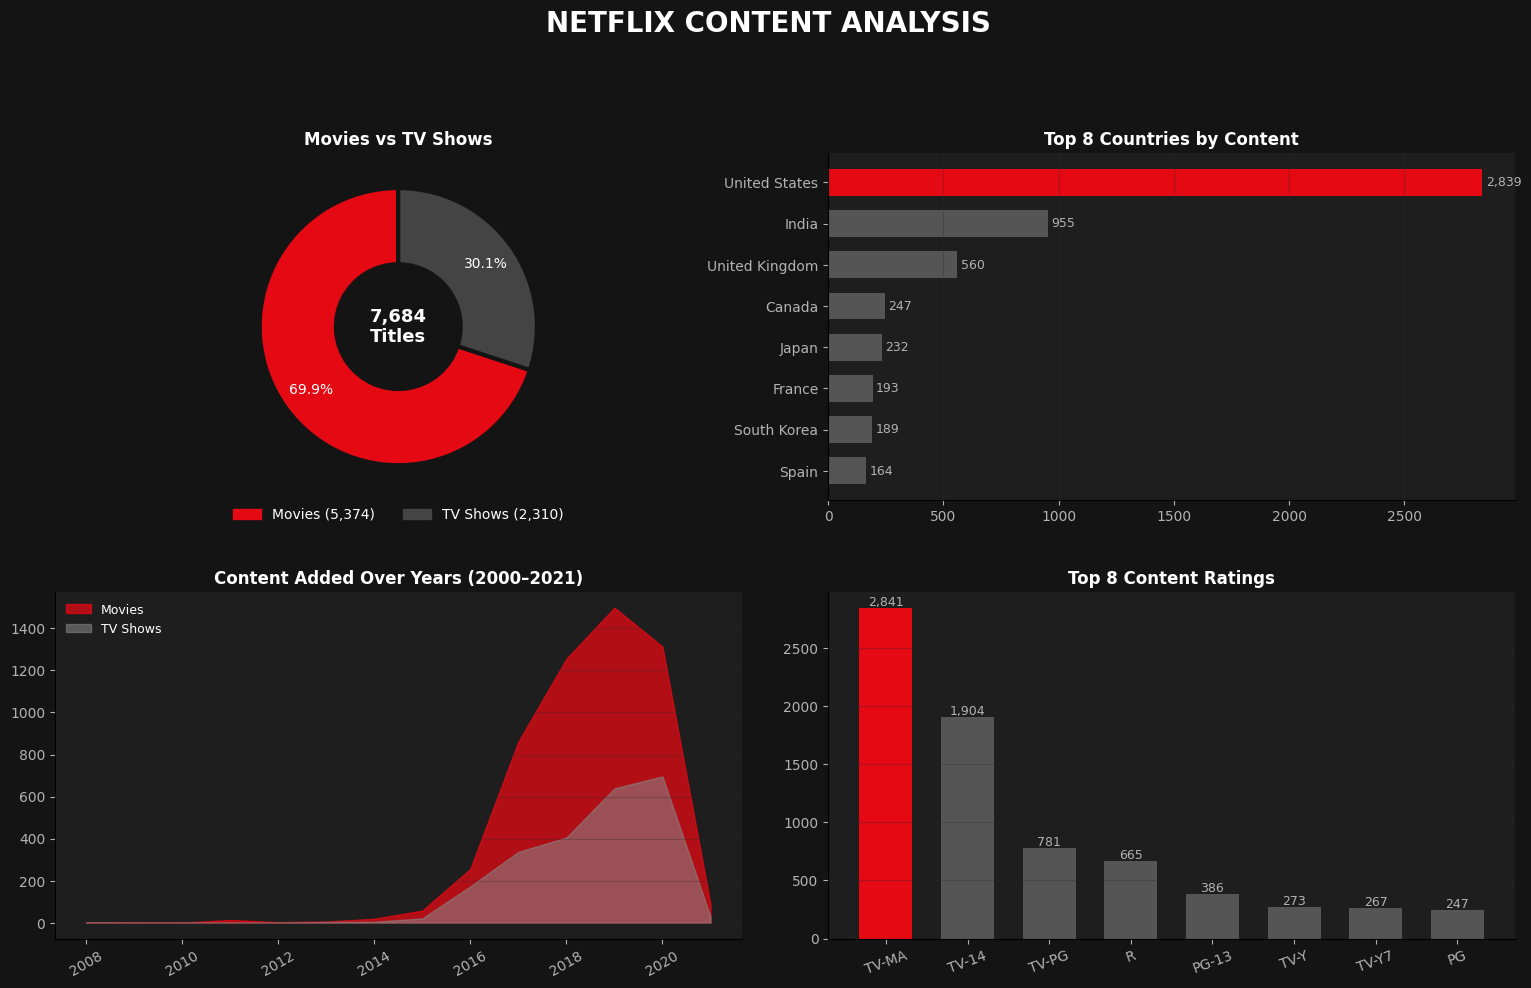

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NETFLIX CONTENT ANALYSIS', 
             fontsize=20, fontweight='bold', y=1.01)

# Chart 1 - Movies vs TV Shows donut
ax1 = axes[0, 0]
ax1.pie(cat_counts, colors=[RED, '#444'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=3),
        pctdistance=0.78)
ax1.text(0, 0, f"{len(df):,}\nTitles",
         ha='center', va='center', fontsize=13, fontweight='bold')
ax1.legend(
    handles=[
        mpatches.Patch(color=RED,    label=f"Movies ({cat_counts.get('Movie', 0):,})"),
        mpatches.Patch(color='#444', label=f"TV Shows ({cat_counts.get('TV Show', 0):,})")
    ],
    loc='lower center', bbox_to_anchor=(0.5, -0.1),
    frameon=False, ncol=2, fontsize=10)
ax1.set_title('Movies vs TV Shows', fontweight='bold')

# Chart 2 - Top 8 countries
ax2 = axes[0, 1]
colors2 = [RED if i == 0 else '#555' for i in range(len(top_country))]
ax2.barh(top_country.index[::-1], top_country.values[::-1],
         color=colors2[::-1], height=0.65)
for i, v in enumerate(top_country.values[::-1]):
    ax2.text(v + 15, i, f'{v:,}', va='center', color=GRAY, fontsize=9)
ax2.set_title('Top 8 Countries by Content', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# Chart 3 - Content growth over years
ax3 = axes[1, 0]
years = trend['Year'].astype(int)
ax3.fill_between(years, trend.get('Movie',   0),
                 alpha=0.75, color=RED,   label='Movies')
ax3.fill_between(years, trend.get('TV Show', 0),
                 alpha=0.55, color='#888', label='TV Shows')
ax3.set_title('Content Added Over Years (2000–2021)', fontweight='bold')
ax3.legend(frameon=False, fontsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)
ax3.tick_params(axis='x', rotation=30)

# Chart 4 - Content ratings
ax4 = axes[1, 1]
colors4 = [RED if i == 0 else '#555' for i in range(len(top_rating))]
ax4.bar(top_rating.index, top_rating.values, color=colors4, width=0.65)
for i, v in enumerate(top_rating.values):
    ax4.text(i, v + 20, f'{v:,}', ha='center', color=GRAY, fontsize=9)
ax4.set_title('Top 8 Content Ratings', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.spines[['top', 'right']].set_visible(False)
ax4.tick_params(axis='x', rotation=20)

plt.tight_layout(pad=3.0)
plt.savefig('netflix_dashboard.png', dpi=150, 
            bbox_inches='tight', facecolor=BG)
plt.show()